# Headless camera streaming (live view)

BeamNG.tech in **headless mode** (`-headless`, GPU required): no window, but camera sensors still render.

This notebook streams **3 cameras at ~20 Hz** and shows live frames in the cell output (no `print()` spam).

**Knobs** (setup cell): `HEADLESS`, `BNG_HOME`, `LAUNCH`, `STEPS`, resolution, etc.

Run cells in order. Use the **cleanup** cell when finished.

In [5]:
from __future__ import annotations

import platform
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

from beamngpy import BeamNGpy, Scenario, Vehicle
from beamngpy.sensors import Camera

# --- knobs ---
HOST = "localhost"
PORT = 25252
# BNG_HOME = r"F:\BeamNG.tech.v0.38.5.0"
LAUNCH = True
HEADLESS = True
GFX = "dx11" if platform.system() == "Windows" else "vk"

LEVEL = "west_coast_usa"
CAMERA_COUNT = 3
UPDATE_TIME_S = 0.05  # 20 Hz
WARMUP_STEPS = 5
STEPS = 60
RESOLUTION = (640, 480)

SPAWN_POS = (-717.121, 101, 118.675)
SPAWN_ROT = (0, 0, 0.3826834, 0.9238795)
CAMERA_OFFSETS = [
    (-0.3, 1.0, 1.2),
    (0.3, 1.0, 1.2),
    (0.0, 1.8, 1.0),
]


def raw_colour_to_rgb(raw: bytes | None, resolution: tuple[int, int]) -> np.ndarray | None:
    if raw is None or len(raw) == 0:
        return None
    w, h = resolution
    arr = np.frombuffer(raw, dtype=np.uint8)
    if len(arr) == h * w * 4:
        return arr.reshape(h, w, 4)[:, :, :3]
    return arr.reshape(h, w, 3)

In [6]:
beamng = BeamNGpy(
    HOST,
    PORT,
    # home=BNG_HOME,
    headless=HEADLESS,
    gfx=GFX,
    quit_on_close=True,
)

scenario = Scenario(LEVEL, "headless_camera_streaming_live")
ego = Vehicle("ego", model="etk800", color="White")
scenario.add_vehicle(ego, pos=SPAWN_POS, rot_quat=SPAWN_ROT)

beamng.open(launch=LAUNCH)
scenario.make(beamng)

beamng.settings.set_deterministic(60)
beamng.control.pause()
beamng.scenario.load(scenario)
beamng.scenario.start()

cameras = []
for i in range(CAMERA_COUNT):
    cameras.append(
        Camera(
            f"cam_{i}",
            beamng,
            ego,
            requested_update_time=UPDATE_TIME_S,
            is_using_shared_memory=True,
            is_streaming=True,
            is_render_colours=True,
            is_render_annotations=False,
            is_render_depth=False,
            resolution=RESOLUTION,
            pos=CAMERA_OFFSETS[i],
            dir=(0, -1, 0),
            field_of_view_y=70,
        )
    )

for _ in range(WARMUP_STEPS):
    beamng.control.step(1)
    for cam in cameras:
        cam.stream_raw()

Cannot close shared memory. Original error: cannot close exported pointers exist


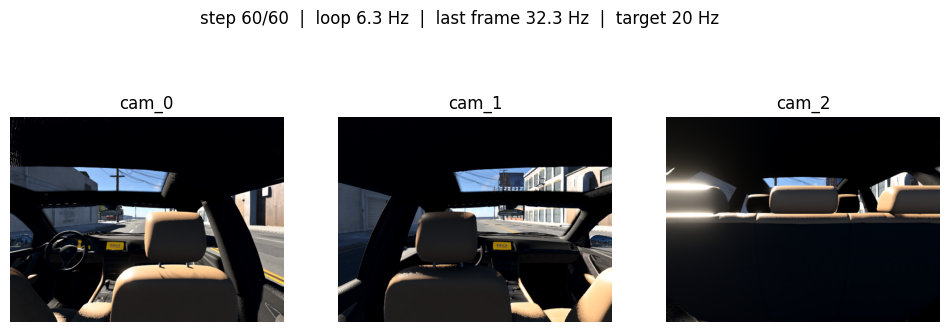

Target sensor rate: 20 Hz (requested_update_time=0.05s)
Measured loop rate: 17.5 Hz over 60 frames
Note: matplotlib display slows the loop; sim-side camera rate can be higher.


In [7]:
fig, axes = plt.subplots(1, CAMERA_COUNT, figsize=(4 * CAMERA_COUNT, 4))
if CAMERA_COUNT == 1:
    axes = [axes]

for ax in axes:
    ax.axis("off")

t0 = time.monotonic()
frame_times = []

for step in range(STEPS):
    frame_t0 = time.monotonic()
    beamng.control.step(1)

    for ax, cam in zip(axes, cameras):
        rgb = raw_colour_to_rgb(cam.stream_raw().get("colour"), RESOLUTION)
        ax.clear()
        ax.axis("off")
        if rgb is not None:
            ax.imshow(rgb)
        ax.set_title(cam.name)

    frame_times.append(time.monotonic() - frame_t0)
    elapsed = time.monotonic() - t0
    loop_hz = (step + 1) / elapsed if elapsed > 0 else 0.0
    last_hz = 1.0 / frame_times[-1] if frame_times[-1] > 0 else 0.0
    target_hz = 1.0 / UPDATE_TIME_S

    fig.suptitle(
        f"step {step + 1}/{STEPS}  |  loop {loop_hz:.1f} Hz  |  last frame {last_hz:.1f} Hz  |  target {target_hz:.0f} Hz",
        y=1.02,
    )
    clear_output(wait=True)
    display(fig)

avg_hz = len(frame_times) / sum(frame_times) if frame_times else 0.0
print(f"Target sensor rate: {target_hz:.0f} Hz (requested_update_time={UPDATE_TIME_S}s)")
print(f"Measured loop rate: {avg_hz:.1f} Hz over {len(frame_times)} frames")
print("Note: matplotlib display slows the loop; sim-side camera rate can be higher.")

plt.close(fig)

In [8]:
for cam in cameras:
    cam.remove()
cameras.clear()

beamng.disconnect()

Cannot close shared memory. Original error: cannot close exported pointers exist
